In [26]:
import pandas as pd

In [27]:
        messages = pd.read_csv('SMSSpamCollection.txt', sep='\t', names=['label', 'message'])
        messages

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [28]:
messages.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [29]:
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

In [30]:
def cleaning(message):
    m = re.sub('[^a-zA-Z]', ' ', message)
    m = m.lower()
    m = m.split()
    m = [ps.stem(word) for word in m if not word in stopwords.words('english')]
    m = ' '.join(m)
    return m

In [31]:
m = "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
cleaning(m)

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [32]:
messages['message_cleaning'] = messages['message'].apply(cleaning)
messages.head()

,label,message,message_cleaning
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,ham,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entri wkli comp win fa cup final tkt st m...
3,ham,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [33]:
messages.shape

(5572, 3)

In [34]:
X = messages['message_cleaning'].values
X

array(['go jurong point crazi avail bugi n great world la e buffet cine got amor wat',
       'ok lar joke wif u oni',
       'free entri wkli comp win fa cup final tkt st may text fa receiv entri question std txt rate c appli',
       ..., 'piti mood suggest',
       'guy bitch act like interest buy someth els next week gave us free',
       'rofl true name'], shape=(5572,), dtype=object)

In [35]:
y = pd.get_dummies(messages['label'])
y

,ham,spam
0,True,False
1,True,False
2,False,True
3,True,False
4,True,False
...,...,...
5567,False,True
5568,True,False
5569,True,False
5570,True,False


In [36]:
y = y.iloc[:, 0].values
y

array([ True,  True, False, ...,  True,  True,  True], shape=(5572,))

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42)

In [38]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer(max_features=2500, ngram_range=(1,2))

In [39]:
X_train = cv.fit_transform(X_train)
X_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 36202 stored elements and shape (4457, 2500)>

In [40]:
X_test = cv.transform(X_test)

In [41]:
cv.vocabulary_

{'repli': np.int64(1724),
 'win': np.int64(2398),
 'weekli': np.int64(2372),
 'world': np.int64(2433),
 'cup': np.int64(461),
 'send': np.int64(1827),
 'stop': np.int64(1993),
 'end': np.int64(591),
 'servic': np.int64(1843),
 'send stop': np.int64(1833),
 'stop end': np.int64(1995),
 'hello': np.int64(914),
 'sort': np.int64(1944),
 'town': np.int64(2180),
 'alreadi': np.int64(48),
 'dont': np.int64(545),
 'rush': np.int64(1770),
 'home': np.int64(950),
 'eat': np.int64(578),
 'let': np.int64(1143),
 'know': np.int64(1087),
 'let know': np.int64(1145),
 'come': np.int64(385),
 'go': np.int64(792),
 'tell': np.int64(2071),
 'told': np.int64(2157),
 'hey': np.int64(917),
 'till': np.int64(2134),
 'dint': np.int64(530),
 'meet': np.int64(1281),
 'even': np.int64(616),
 'singl': np.int64(1885),
 'time': np.int64(2135),
 'saw': np.int64(1791),
 'situat': np.int64(1893),
 'orang': np.int64(1505),
 'bring': np.int64(213),
 'rington': np.int64(1750),
 'chart': np.int64(325),
 'free': np.int64

In [51]:
from sklearn.naive_bayes import MultinomialNB

spam_model = MultinomialNB()
spam_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [43]:
y_pred = spam_model.predict(X_test)
y_pred

array([ True,  True,  True, ...,  True,  True,  True], shape=(1115,))

In [44]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.9838565022421525

In [45]:
y_pred_train = spam_model.predict(X_train)

In [46]:
accuracy_score(y_train, y_pred_train)

0.9876598608929773

In [47]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.95      0.93      0.94       149
        True       0.99      0.99      0.99       966

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[138  11]
 [  7 959]]


In [49]:
import matplotlib.pyplot as plt

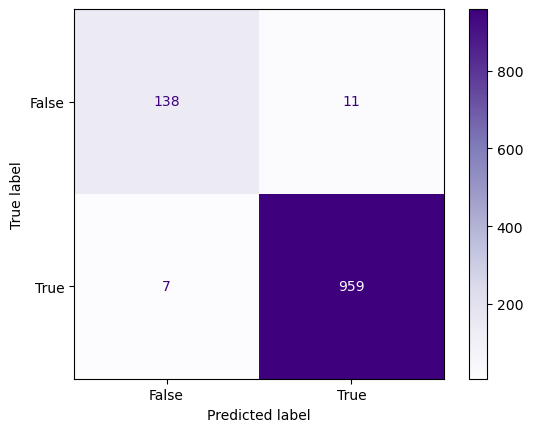

In [50]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, 
    display_labels=spam_model.classes_)

disp.plot(cmap="Purples")
plt.show()